In [15]:
# Import necessary libraries
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder

# Set dataset path dynamically
dataset_path = os.path.join("C:/Users/saira/OneDrive/Desktop/DePaul/DSC540/Project", "diabetic_data.csv")
df = pd.read_csv(dataset_path)

# Create a copy to avoid modifying the original
df_cleaned = df.copy()

# Replace missing values denoted as "?" with NaN
df_cleaned.replace("?", pd.NA, inplace=True)

# Drop columns with excessive missing values
df_cleaned.drop(columns=['weight', 'payer_code', 'medical_specialty'], inplace=True)

# Remove unknown gender values
df_cleaned = df_cleaned[df_cleaned['gender'] != 'Unknown/Invalid']

# Fill missing categorical values with 'Unknown' where appropriate
df_cleaned.fillna({'race': 'Unknown', 'max_glu_serum': 'None', 'A1Cresult': 'None'}, inplace=True)

# Convert 'readmitted' into a binary classification: (1 = <30 days, 0 = otherwise)
df_cleaned['readmitted'] = df_cleaned['readmitted'].map({'NO': 0, '>30': 0, '<30': 1})

# Remove encounters where discharge disposition indicates hospice or patient death
hospice_discharge_codes = ['11', '13', '14', '19', '20', '21']
df_cleaned = df_cleaned[~df_cleaned['discharge_disposition_id'].astype(str).isin(hospice_discharge_codes)]

# Define a function to categorize ICD-9 codes into broader categories
def categorize_icd9(code):
    try:
        code = str(code).strip()
        if code.startswith('V') or code.startswith('E') or code == 'nan' or code == '':
            return 0  # Non-disease codes

        code = float(code)
        if 390 <= code <= 459 or int(code) == 785:
            return 1  # Circulatory
        elif 460 <= code <= 519 or int(code) == 786:
            return 2  # Respiratory
        elif 520 <= code <= 579 or int(code) == 787:
            return 3  # Digestive
        elif int(code) == 250:
            return 4  # Diabetes
        elif 800 <= code <= 999:
            return 5  # Injury
        elif 710 <= code <= 739:
            return 6  # Musculoskeletal
        elif 580 <= code <= 629 or int(code) == 788:
            return 7  # Genitourinary
        elif 140 <= code <= 239:
            return 8  # Neoplasms (Cancer)
        else:
            return 0  # Other/Unclassified
    except:
        return 0

# Apply the ICD-9 categorization function to diagnosis columns
df_cleaned['ICDCat1'] = df_cleaned['diag_1'].apply(categorize_icd9)
df_cleaned['ICDCat2'] = df_cleaned['diag_2'].apply(categorize_icd9)
df_cleaned['ICDCat3'] = df_cleaned['diag_3'].apply(categorize_icd9)

# Drop original diagnosis columns after transformation
df_cleaned.drop(columns=['diag_1', 'diag_2', 'diag_3'], inplace=True)

# Aggregate all prior inpatient, emergency, and outpatient encounters
df_cleaned['num_visits'] = df_cleaned['number_outpatient'] + df_cleaned['number_emergency'] + df_cleaned['number_inpatient']

# Convert age group to numeric midpoints
age_mapping = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
df_cleaned['age'] = df_cleaned['age'].map(age_mapping).astype(int)  # Ensure it becomes an integer


# Convert categorical features into numeric representations
df_cleaned['gender'] = df_cleaned['gender'].map({'Male': 1, 'Female': 0}).astype(int)
df_cleaned['change'] = df_cleaned['change'].map({'Ch': 1, 'No': 0}).astype(int)
df_cleaned['diabetesMed'] = df_cleaned['diabetesMed'].map({'Yes': 1, 'No': 0}).astype(int)

# Label Encoding for high-cardinality categorical features
label_enc_cols = ['discharge_disposition_id', 'admission_source_id']
le = LabelEncoder()
for col in label_enc_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))  # Convert to string before encoding

# Keep one-hot encoding for low-cardinality categorical features
categorical_columns = ['race', 'max_glu_serum', 'A1Cresult']
df_cleaned = pd.get_dummies(df_cleaned, columns=categorical_columns, drop_first=True)

# Apply logarithmic transformation to highly skewed numerical columns
for col in ['number_inpatient', 'number_emergency', 'number_outpatient', 'num_visits','num_medications']:
    df_cleaned[f'{col}_log'] = np.log1p(df_cleaned[col])

# Drop original untransformed visit columns
df_cleaned.drop(columns=['number_inpatient', 'number_emergency', 'number_outpatient', 'num_visits'], inplace=True)

# Ensure only required log-transformed columns remain
df_cleaned.drop(columns=['number_inpatient_log', 'number_emergency_log', 'number_outpatient_log','num_medications'], inplace=True, errors='ignore')

# Drop unnecessary features before encoding
df_cleaned.drop(columns=['encounter_id', 'patient_nbr'], inplace=True)  # Not useful for prediction

"""
# Drop redundant medication columns after feature engineering (only if they exist)
medications_to_drop = [
    'examide', 'citoglipton',  # These columns have only one value (redundant)
    'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 
    'metformin-rosiglitazone', 'metformin-pioglitazone'  # Rarely prescribed medications]

df_cleaned.drop(columns=[col for col in medications_to_drop if col in df_cleaned.columns], inplace=True)

"""
medications = [
    'examide', 'citoglipton','metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 
    'insulin', 'glyburide-metformin', 'glipizide-metformin', 
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]
df_cleaned.drop(columns=medications, inplace=True)


# Save the cleaned dataset dynamically
cleaned_data_path = os.path.join("C:/Users/saira/OneDrive/Desktop/DePaul/DSC540/Project", "final_cleaned_diabetic_data.csv")
df_cleaned.to_csv(cleaned_data_path, index=False)

print("Preprocessing complete! Saved cleaned data at:", cleaned_data_path)


Preprocessing complete! Saved cleaned data at: C:/Users/saira/OneDrive/Desktop/DePaul/DSC540/Project\final_cleaned_diabetic_data.csv


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [17]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99340 entries, 0 to 101765
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   gender                    99340 non-null  int32  
 1   age                       99340 non-null  int32  
 2   admission_type_id         99340 non-null  int64  
 3   discharge_disposition_id  99340 non-null  int32  
 4   admission_source_id       99340 non-null  int32  
 5   time_in_hospital          99340 non-null  int64  
 6   num_lab_procedures        99340 non-null  int64  
 7   num_procedures            99340 non-null  int64  
 8   number_diagnoses          99340 non-null  int64  
 9   change                    99340 non-null  int32  
 10  diabetesMed               99340 non-null  int32  
 11  readmitted                99340 non-null  int64  
 12  ICDCat1                   99340 non-null  int64  
 13  ICDCat2                   99340 non-null  int64  
 14  ICDCat3   

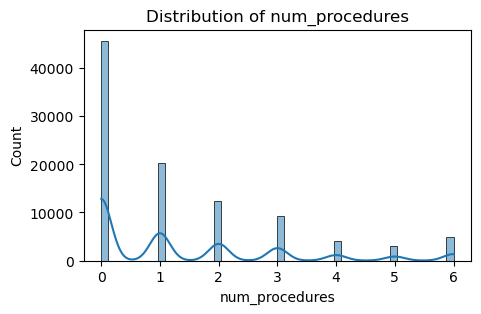

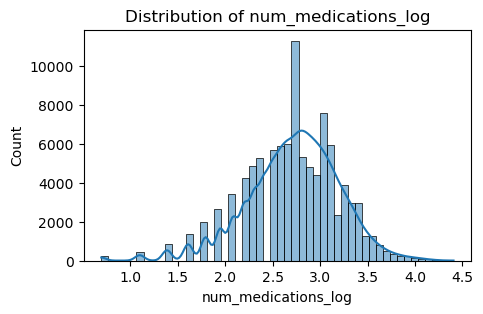

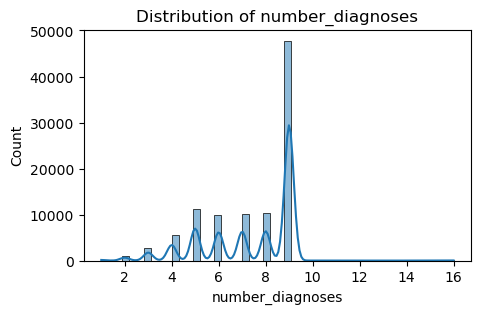

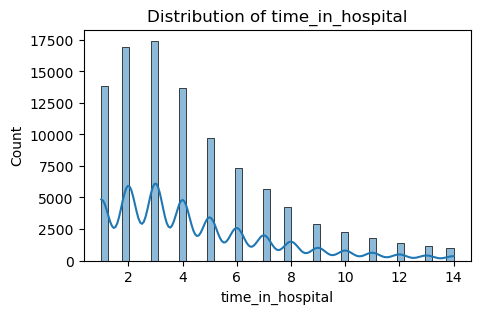

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize distribution of numerical features
numeric_features = ['num_procedures', 'num_medications_log', 'number_diagnoses', 'time_in_hospital']
for col in numeric_features:
    plt.figure(figsize=(5,3))
    sns.histplot(df_cleaned[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


In [25]:
readmission_percentage = df_cleaned['readmitted'].value_counts(normalize=True) * 100
print("\nReadmission Distribution (Percentage):")
print(readmission_percentage)


Readmission Distribution (Percentage):
readmitted
0    88.610831
1    11.389169
Name: proportion, dtype: float64
